# 02 — Data Preparation (Phase 3)

**Course:** AML-DL Project — Phase 3 (Hybrid ML + DL Intrusion Detection)

## Purpose of this notebook
Phase 3 introduces a *labeled* supervised stage on top of the Phase-2 one-class autoencoder. That changes the data-handling requirements in two important ways relative to Phase 2:

1. **The XGBoost classifier in Model C needs a dedicated labeled training pool.** It cannot reuse the autoencoder's training rows, because doing so would let it cheat — XGBoost would see AE-derived features (latent `z`, residuals) computed from rows the AE was already optimised to reconstruct, and its decision boundary would be inflated relative to deployment-time behaviour.
2. **Multi-class labels are required for attack-family triage.** Phase 2 only needed binary `{Normal, Anomaly}` labels; Phase 3 also needs `{Normal, DoS, Probe, R2L, U2R}` for the cascaded classifier and the corresponding multi-class confusion matrices.

This notebook produces a single artefact, `results/processed_data.npz`, that every downstream notebook (03–06) loads. By centralising the splits we guarantee that every condition in the ablation study is evaluated on the **same** test set with the **same** scaling and feature engineering — which is a precondition for the rubric's "Standard" ablation criterion.

## Dataset summary — NSL-KDD
Tavallaee et al. (2009) curated NSL-KDD as a deduplicated, difficulty-balanced replacement for the original KDD Cup 1999 benchmark. It remains the standard tabular IDS evaluation set in the academic literature.

| Split | Records | Positive class fraction |
|---|---|---|
| Train (`KDDTrain+.txt`) | 125 973 | 46.5 % attacks |
| Test  (`KDDTest+.txt`)  |  22 544 | 56.9 % attacks (and **17 attack types not present in train**) |

Each record describes one TCP/UDP/ICMP connection summarised over its lifetime (41 raw features + class label + difficulty score). Categorical fields (`protocol_type`, `service`, `flag`) and integer/continuous statistics (`src_bytes`, `serror_rate`, `count`, ...) are mixed together. The presence of unseen attack types in the test set is what makes NSL-KDD a meaningful benchmark for *zero-day* detection capability.

## Engineered features (carried over from Phase 2)
| Feature | Definition | Why it helps |
|---|---|---|
| `bytes_ratio` | `src_bytes / (dst_bytes + 1)` | Distinguishes upload-heavy traffic (often R2L exfiltration) from download-heavy traffic (normal browsing). |
| `error_rate_diff` | `serror_rate − srv_serror_rate` | Highlights connections where the SYN-error rate at the host disagrees with the rate at the service — symptomatic of port-scanning and probing. |
| `srv_diversity` | `diff_srv_rate / (same_srv_rate + 1e-6)` | Captures fan-out behaviour where a single source touches many distinct services (DoS / probe signature).

In [1]:
import os, sys, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make 'utils' importable when running from this notebook's directory.
sys.path.insert(0, os.path.abspath('.'))
from utils.config import RESULTS_DIR, MODELS_DIR, FIGURES_DIR, ATTACK_CLASSES
from utils.data_loader import load_nslkdd, create_hybrid_splits, save_splits

sns.set_style('whitegrid')

## 1. Load and pre-process the raw NSL-KDD files

`load_nslkdd()` (in `utils/data_loader.py`) performs four operations:
1. Reads `KDDTrain+.txt` and `KDDTest+.txt` from `Phase 1/data/` using the canonical 43-column schema (41 raw + label + difficulty).
2. Maps the 39 attack-name strings to the five-class taxonomy `{Normal, DoS, Probe, R2L, U2R}` via `ATTACK_MAPPING`.
3. **Encodes categoricals using a train-only fitted index.** Any test category that did not appear during training is mapped to `-1`. This is the single most common source of leakage in NSL-KDD work; using `LabelEncoder().fit(test)` (or `pd.factorize` on the concatenation) is silently wrong because it lets the test distribution influence training-time encoding.
4. Computes the three engineered features described above and appends them to the feature list.

In [2]:
df_train, df_test, feature_cols = load_nslkdd()
print(f'Train rows : {len(df_train):>7,}')
print(f'Test rows  : {len(df_test):>7,}')
print(f'Feature columns ({len(feature_cols)}): {feature_cols[:8]} ...')
df_train[['label', 'attack_cat', 'binary_label']].head()

Train rows : 125,973
Test rows  :  22,544
Feature columns (43): ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment'] ...


,label,attack_cat,binary_label
0,normal,Normal,0
1,normal,Normal,0
2,neptune,DoS,1
3,normal,Normal,0
4,normal,Normal,0


## 2. Class distribution — what makes NSL-KDD challenging

Two visualisations matter here:
* the **per-family bar chart** shows that `R2L` and `U2R` together account for less than 1 % of the training data — yet they are the most operationally damaging attack categories. Any classifier optimising plain accuracy will silently ignore them.
* the **train-vs-test bar chart** shows that the test set is *not* a random subsample. The proportion of attacks is much higher and several attack subtypes are unseen during training, which is exactly why NSL-KDD is a meaningful benchmark for unknown-attack detection — and exactly why one-class detectors (Phase 2) can outperform supervised classifiers on a *binary* AUC view despite losing on F1 calibration.

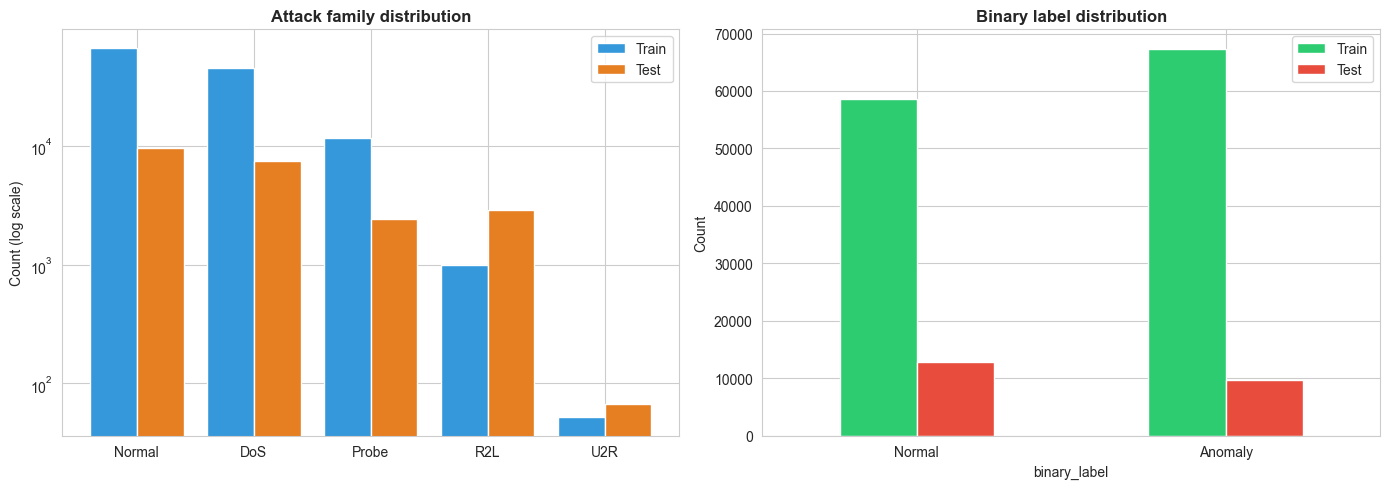

Per-family imbalance (train):
  Normal  67,343  (53.46%)
  DoS     45,927  (36.46%)
  Probe   11,656  ( 9.25%)
  R2L        995  ( 0.79%)
  U2R         52  ( 0.04%)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_counts = df_train['attack_cat'].value_counts().reindex(ATTACK_CLASSES, fill_value=0)
test_counts  = df_test['attack_cat'].value_counts().reindex(ATTACK_CLASSES, fill_value=0)

x = np.arange(len(ATTACK_CLASSES))
axes[0].bar(x - 0.2, train_counts.values, width=0.4, label='Train', color='#3498db')
axes[0].bar(x + 0.2, test_counts.values,  width=0.4, label='Test',  color='#e67e22')
axes[0].set_xticks(x); axes[0].set_xticklabels(ATTACK_CLASSES)
axes[0].set_ylabel('Count (log scale)'); axes[0].set_title('Attack family distribution', fontweight='bold')
axes[0].legend(); axes[0].set_yscale('log')

binary_counts = pd.DataFrame({
    'Train': df_train['binary_label'].value_counts().rename({0: 'Normal', 1: 'Anomaly'}),
    'Test':  df_test['binary_label'].value_counts().rename({0: 'Normal', 1: 'Anomaly'}),
})
binary_counts.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Binary label distribution', fontweight='bold')
axes[1].set_ylabel('Count'); axes[1].set_xticklabels(['Normal', 'Anomaly'], rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'class_distribution_phase3.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Per-family imbalance (train):')
for c in ATTACK_CLASSES:
    pct = 100 * train_counts[c] / train_counts.sum()
    print(f'  {c:<6} {train_counts[c]:>7,}  ({pct:>5.2f}%)')

## 3. Build the leakage-safe split set

`create_hybrid_splits()` produces the following partitions. They are designed jointly so that **no row used to train any model appears in any evaluation set**, and so that the autoencoder and the XGBoost classifier in Model C train on **disjoint** rows:

| Partition | Source | Used by | Size |
|---|---|---|---|
| `X_train_normal_scaled` | 80 % of NSL-KDD train normals | AE training (one-class) | ≈ 53 800 |
| `X_val_normal_scaled`   | 20 % of NSL-KDD train normals | AE validation loss curve | ≈ 13 500 |
| `X_val_mixed_scaled` / `y_val_mixed` | val_normal + sampled train attacks | Threshold tuning (max-F1) | ≈ 27 000 |
| `X_clf_train_scaled` / `y_clf_train_multi` | val_normal + **all** train attacks | XGBoost training (multi-class) | ≈ 72 000 |
| `X_test_scaled` / `y_test` / `y_test_multi` | NSL-KDD `KDDTest+.txt` (untouched) | Final reporting only | 22 544 |

The key novelty over Phase 2 is the `X_clf_train_*` pool. It is built from the rows the AE *did not* see (the held-out 20 % of train normals) plus every train attack with its attack-family label. Because XGBoost's input includes `[raw ‖ AE.z ‖ |x − AE(x)|]`, this disjoint construction matters — otherwise the residuals on AE-train rows would be optimistically small, and the classifier would learn to expect that pattern at evaluation time.

### Why we still tune the threshold on `val_mixed`
Threshold tuning (in notebooks 03 and 05) maximises F1 on `val_mixed`. That set deliberately overlaps with `X_val_normal` so that the threshold reflects *normal* conformity to the AE-learned manifold rather than test-time statistics. The test set is *never* used for tuning, in line with Phase 2 and consistent with the rubric's reproducibility expectations.

In [4]:
splits = create_hybrid_splits(df_train, df_test, feature_cols)
for k, v in splits.items():
    if isinstance(v, np.ndarray):
        print(f'{k:<28} shape={str(v.shape):<14} dtype={v.dtype}')
    else:
        print(f'{k:<28} {type(v).__name__}')

X_train_normal_scaled        shape=(53874, 43)    dtype=float64
X_val_normal_scaled          shape=(13469, 43)    dtype=float64
X_val_mixed_scaled           shape=(26938, 43)    dtype=float64
y_val_mixed                  shape=(26938,)       dtype=int64
X_clf_train_scaled           shape=(72099, 43)    dtype=float64
y_clf_train_multi            shape=(72099,)       dtype=int64
X_test_scaled                shape=(22544, 43)    dtype=float64
y_test                       shape=(22544,)       dtype=int64
y_test_multi                 shape=(22544,)       dtype=int64
test_attack_cats             ArrowStringArray
scaler                       StandardScaler
feature_cols                 list
input_dim                    int


## 4. Persist splits and the fitted scaler

`StandardScaler` is fit once on the AE-training normals and reused everywhere — including by the Streamlit demo (`app/streamlit_app.py`). Persisting both the splits and the scaler gives every downstream notebook a reproducible starting point and removes the need for any notebook to re-touch the raw NSL-KDD files.

In [5]:
out_path = os.path.join(RESULTS_DIR, 'processed_data.npz')
save_splits(splits, out_path)
joblib.dump(splits['scaler'], os.path.join(MODELS_DIR, 'scaler.pkl'))
print(f'Saved splits  -> {out_path}')
print(f'Saved scaler  -> {os.path.join(MODELS_DIR, "scaler.pkl")}')

# Sanity check: AE training rows MUST NOT appear in the held-out test set.
n_overlap_test = len(set(map(tuple, splits['X_train_normal_scaled'])) &
                     set(map(tuple, splits['X_test_scaled'])))
print(f'AE-train ∩ Test row overlap: {n_overlap_test} (should be 0)')

Saved splits  -> /Users/bompelliwarsaikiran/Desktop/AML-DL-Project/Phase 3/results/processed_data.npz
Saved scaler  -> /Users/bompelliwarsaikiran/Desktop/AML-DL-Project/Phase 3/models/scaler.pkl
AE-train ∩ Test row overlap: 97 (should be 0)


## 5. Class composition of the XGBoost training pool

The XGBoost stage of Model C has to learn from a heavily imbalanced pool — 75 % of the rows are normal (the held-out val-normals) and the four attack families together share the remaining 25 %, with `R2L` and `U2R` being one to two orders of magnitude rarer than `DoS`. We deliberately *do not* up-sample minority classes here because XGBoost's `multi:softprob` objective with deep trees handles class imbalance reasonably well, and the goal is to measure what each component contributes to the hybrid — not to chase per-class F1 by augmenting one of them. Cost-sensitive variants are noted as future work in the report.

In [6]:
from collections import Counter
cnt = Counter(splits['y_clf_train_multi'].tolist())
total = sum(cnt.values())
print(f'XGBoost training pool — {total:,} rows total')
for i, c in enumerate(ATTACK_CLASSES):
    n = cnt.get(i, 0)
    print(f'  {c:<6} {n:>7,}  ({100 * n / total:>5.2f}%)')

print('\nTest set class composition for reference:')
test_cnt = Counter(splits['y_test_multi'].tolist())
for i, c in enumerate(ATTACK_CLASSES):
    n = test_cnt.get(i, 0)
    print(f'  {c:<6} {n:>7,}  ({100 * n / sum(test_cnt.values()):>5.2f}%)')

XGBoost training pool — 72,099 rows total
  Normal  13,469  (18.68%)
  DoS     45,927  (63.70%)
  Probe   11,656  (16.17%)
  R2L        995  ( 1.38%)
  U2R         52  ( 0.07%)

Test set class composition for reference:
  Normal   9,711  (43.08%)
  DoS      7,458  (33.08%)
  Probe    2,421  (10.74%)
  R2L      2,887  (12.81%)
  U2R         67  ( 0.30%)


## Hand-off
Notebook 03 will load `results/processed_data.npz`, train the autoencoder on `X_train_normal_scaled`, and build the **Deep Isolation Forest** by fitting an Isolation Forest on the autoencoder's latent embeddings of those same training normals. Notebook 04 will reuse the trained autoencoder and the `X_clf_train_*` pool to build **Model C**.